# Phase 4 — Uncertainty and calibration

A biomarker detector that outputs 0.9 should be right about 90% of the time it says 0.9. Nothing
in the training objective enforces that, and with `pos_weight` deliberately distorting the loss to
handle imbalance, the raw probabilities are almost certainly miscalibrated.

This phase answers three separate questions that are easy to conflate:

| Question | Tool | What it is *not* |
|---|---|---|
| Are the probabilities honest? | Temperature scaling, ECE, reliability | Not about ranking — AUROC is unchanged |
| How confident is the model, per case? | MC dropout | Not proof of correctness |
| Can we flag cases for human review? | Selective prediction | Not a clinical deployment claim |

### The trap this notebook is built around

**Low variance is not evidence of correctness.** A confidently wrong model produces low variance
too. The whole point of section 5 is to test whether uncertainty actually tracks error on *this*
data, rather than assuming it does.

---
## 1. Setup and run selection

In [1]:
import importlib
import os
import subprocess
import sys
import time
import warnings
from pathlib import Path

try:
    from google.colab import drive
except ImportError as error:
    raise RuntimeError(
        f"This notebook requires a Google Colab runtime; active Python is {sys.executable}"
    ) from error

drive.mount("/content/drive")

# /content is temporary, so restore the source checkout whenever Colab assigns a new VM.
REPO_ROOT = Path("/content/ClinBioGate")
PACKAGE_FILE = REPO_ROOT / "src" / "olives_biomarkers" / "__init__.py"
if not PACKAGE_FILE.is_file():
    if REPO_ROOT.exists():
        raise RuntimeError(f"{REPO_ROOT} exists but is not a complete repository")
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/PasBless1/ClinBioGate.git",
            str(REPO_ROOT),
        ],
        check=True,
    )

os.chdir(REPO_ROOT)
SRC_DIR = str(REPO_ROOT / "src")
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)
importlib.invalidate_caches()

warnings.filterwarnings("ignore", category=FutureWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

from olives_biomarkers import ExperimentRunner, OlivesPipeline, RunEvaluator, RunResult
from olives_biomarkers.config import ConfigLoader
from olives_biomarkers.evaluation import (
    CalibrationEvaluator,
    ResultsPlotter,
    SelectivePredictor,
)
from olives_biomarkers.models import ModelFactory
from olives_biomarkers.training import CheckpointManager

assert torch.cuda.is_available(), (
    "CUDA is unavailable. Select Runtime -> Change runtime type -> A100 GPU, "
    "restart, and rerun this cell."
)

pipeline = OlivesPipeline.from_config(
    REPO_ROOT / "configs" / "data.yaml",
    repo_root=REPO_ROOT,
)
loader = ConfigLoader(REPO_ROOT)

BUDGET = "colab_gpu"
RUNS_DIR = Path("/content/drive/MyDrive/olives/outputs/runs/colab_gpu")
FIGURES = Path("/content/drive/MyDrive/olives/outputs/figures/phase4")
RUNS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plotter = ResultsPlotter()


def show(figure, name):
    if figure is None:
        print(f"(no figure for {name})")
        return
    path = FIGURES / f"{name}.png"
    plotter.save(figure, path)
    plt.show()
    print(f"saved: {path}")


print(f"python={sys.executable}")
print(f"package={PACKAGE_FILE}")
print(f"device={pipeline.env.device} ({torch.cuda.get_device_name(0)})")
print(f"data={pipeline.data_root}")
print(f"runs={RUNS_DIR}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
python=/usr/bin/python3
package=/content/ClinBioGate/src/olives_biomarkers/__init__.py
device=cuda (NVIDIA A100-SXM4-80GB)
data=/content/drive/MyDrive/olives/data/raw/OLIVES
runs=/content/drive/MyDrive/olives/outputs/runs/colab_gpu


### Persistent A100 checkpoint recovery

Calibration requires a completed checkpoint, saved predictions and the resolved training
configuration. Colab deletes files under `/content` whenever it replaces the runtime, so this
notebook stores runs and figures in Google Drive. If no completed run is available, the next cell
trains one full-budget OCT baseline and saves it directly to Drive before continuing. This fallback
unblocks Phase 4; the final A-D comparison still belongs in Phases 2-3.

In [2]:
# Load completed Drive-backed runs. If none exist, train one OCT baseline so the
# calibration workflow has a real checkpoint to analyse. Set this to False if
# you prefer the notebook to stop instead of starting a training run.
TRAIN_IF_MISSING = True
FALLBACK_CONFIG = "baseline_oct.yaml"

available = RunResult.load_all(RUNS_DIR)
print(f"{len(available)} completed Drive-backed runs found")

if not available and TRAIN_IF_MISSING:
    print("No checkpoint found; preparing a persistent A100 OCT baseline run.")

    # Keep the 2.3 GB PNG cache in Drive while exposing it at the path expected
    # by OlivesPipeline inside the temporary /content checkout.
    persistent_cache = Path(
        "/content/drive/MyDrive/olives/data/processed/images_labelled"
    )
    local_cache = REPO_ROOT / "data" / "processed" / "images_labelled"
    persistent_cache.mkdir(parents=True, exist_ok=True)
    local_cache.parent.mkdir(parents=True, exist_ok=True)
    if not local_cache.exists():
        local_cache.symlink_to(persistent_cache, target_is_directory=True)

    manifest = pipeline.get_manifest()
    if next(persistent_cache.glob("*.png"), None) is None:
        print("Exporting the modelling image cache to Drive (one-off step)...")
        pipeline.export_image_cache(manifest)

    config = loader.load(REPO_ROOT / "configs" / FALLBACK_CONFIG)
    budget = loader.load(REPO_ROOT / "configs" / "colab_gpu.yaml")
    config.data.image_size = budget.data.image_size
    config.data.num_workers = budget.data.num_workers
    config.training.epochs = budget.training.epochs
    config.training.batch_size = budget.training.batch_size
    config.training.learning_rate = budget.training.learning_rate
    config.training.early_stopping_patience = budget.training.early_stopping_patience
    config.training.amp = budget.training.amp

    assignment = pipeline.make_holdout_split(manifest, write=False)
    frame = pipeline.modelling_frame(manifest, attach_cache=True)
    runner = ExperimentRunner(pipeline, config, output_root=RUNS_DIR)
    run_id = "baseline_oct_holdout_seed42_a100"  # stable ID enables restart/resume
    result = runner.run(
        manifest=manifest,
        assignment=assignment,
        frame=frame,
        seed=42,
        run_id=run_id,
    )
    available = [result]

if not available:
    raise RuntimeError(
        f"No completed runs found in {RUNS_DIR}. Train a model first or set "
        "TRAIN_IF_MISSING=True."
    )

for run in available:
    auprc = run.test_metrics.get("macro_auprc", float("nan"))
    print(f"  {run.run_id:48s} {run.model_name:16s} macro_auprc={auprc:.4f}")

# Preserve the notebook's original default: analyse the strongest available run.
result = max(available, key=lambda run: run.test_metrics.get("macro_auprc", -1))
print(f"\nselected: {result.run_id} ({result.model_name})")

1 completed Drive-backed runs found
  oct_only_holdout_seed42_a100_20260828_190437     oct_only         macro_auprc=0.5476

selected: oct_only_holdout_seed42_a100_20260828_190437 (oct_only)


In [3]:
# Rebuild the data module and model so MC dropout can run stochastic passes.
manifest = pipeline.get_manifest()
config = loader.load(result.run_dir / "resolved_config.yaml")
runner = ExperimentRunner(pipeline, config, output_root=RUNS_DIR)

frame = pipeline.modelling_frame(manifest, attach_cache=runner.needs_images)
assignment = pipeline.make_holdout_split(manifest, write=False)
data = runner.build_data_module(frame, assignment, manifest.label_columns)

model = ModelFactory().build(
    config.model, n_labels=len(manifest.label_columns), clinical_dim=data.preprocessor.output_dim
)
CheckpointManager(result.run_dir / "checkpoints", run_id=result.run_id).load(
    model, map_location=pipeline.env.device
)
model.to(pipeline.env.device)
print(f"restored {config.model.name} with {model.n_parameters():,} trainable parameters")

13:33:13 | INFO    | olives.pipeline | loading cached manifest: /content/ClinBioGate/data/manifests/disease_classification_train.parquet
13:33:14 | WARNING | olives.pipeline | image cache not found at /content/ClinBioGate/data/processed/images_labelled; call export_image_cache() for much faster training
13:33:14 | INFO    | olives.splits | holdout split 'holdout': train=52 val=13 test=13 calibration=9 patients
13:33:14 | WARNING | olives.experiment | no image cache found; reading images straight from parquet, which is much slower. Run ImageCacheExporter once to avoid this.
13:33:14 | INFO    | olives.preprocessing | ClinicalPreprocessor fitted on 5672 rows / 52 patients: {'bcva': 78.0, 'cst': 284.0}
13:33:16 | INFO    | olives.dataset | partition 'train': 5672 rows, 52 patients
13:33:16 | INFO    | olives.dataset | partition 'val': 1470 rows, 13 patients
13:33:16 | INFO    | olives.dataset | partition 'test': 1372 rows, 13 patients
13:33:16 | INFO    | olives.dataset | partition 'calib

---
## 2. Calibration

Temperature scaling divides each label's logits by a single learned scalar. It cannot reorder
predictions, so AUROC and AUPRC are untouched — it only fixes systematic over- or
under-confidence, which is exactly what Brier score and ECE measure.

The temperature is fitted on the **calibration partition**: patients held out from training,
validation *and* test. Fitting it on test would be reporting a number the model was tuned on.

In [4]:
evaluator = RunEvaluator(result, model, data, device=pipeline.env.device, seed=config.project.seed)
calibration = evaluator.calibrate()

print(f"temperature fitted on {len(result.predictions['calibration']['targets'])} calibration "
      f"scans from {len(np.unique(result.predictions['calibration']['patient_id']))} patients")
print()
display(pd.DataFrame({
    "label": result.label_names,
    "temperature": np.round(evaluator.scaler.state.temperatures, 4),
}))
print("T > 1 means the model was overconfident and probabilities are being softened.")
print("T = 1.0 exactly means the label was single-class in the calibration fold and was skipped.")

13:33:20 | WARNING | olives.calibration | label 'atrophy_thinning' is single-class in the calibration fold; temperature fixed at 1.0
13:33:21 | WARNING | olives.calibration | label 'vmt' is single-class in the calibration fold; temperature fixed at 1.0
13:33:21 | WARNING | olives.calibration | label 'rpe_disruption' is single-class in the calibration fold; temperature fixed at 1.0
13:33:21 | WARNING | olives.calibration | label 'ped_serous' is single-class in the calibration fold; temperature fixed at 1.0
13:33:21 | INFO    | olives.calibration | fitted temperatures on 882 calibration rows: [1.0, 1.303, 1.967, 1.464, 1.321, 3.889, 3.202, 3.207, 2.15, 1.0, 1.155, 1.42, 1.14, 1.0, 1.0, 0.797]
temperature fitted on 882 calibration scans from 9 patients



,label,temperature
0,atrophy_thinning,1.0000
1,ez_disruption,1.3034
2,dril,1.9675
3,ir_hemorrhages,1.4643
4,irhrf,1.3212
5,pavf,3.8887
6,favf,3.2024
7,preretinal_tissue,3.2074
8,vitreous_debris,2.1504
9,vmt,1.0000


T > 1 means the model was overconfident and probabilities are being softened.
T = 1.0 exactly means the label was single-class in the calibration fold and was skipped.


In [5]:
calibration[["label", "n_positive", "ece_pre", "ece_post", "ece_delta",
             "brier_pre", "brier_post", "brier_delta", "reliable"]]

,label,n_positive,ece_pre,ece_post,ece_delta,brier_pre,brier_post,brier_delta,reliable
0,atrophy_thinning,31,0.0256,0.0256,-0.0000,0.0266,0.0266,0.0000,True
1,ez_disruption,60,0.0627,0.0736,0.0109,0.0619,0.0604,-0.0015,True
2,dril,0,0.0189,0.0553,0.0364,0.0092,0.0126,0.0034,False
3,ir_hemorrhages,53,0.0557,0.0408,-0.0148,0.0551,0.0522,-0.0029,True
4,irhrf,973,0.0913,0.0965,0.0052,0.1349,0.1324,-0.0025,True
5,pavf,278,0.0946,0.1439,0.0493,0.1219,0.1313,0.0094,True
6,favf,873,0.1820,0.1108,-0.0712,0.2176,0.1903,-0.0273,True
7,preretinal_tissue,145,0.1312,0.1127,-0.0185,0.1332,0.1182,-0.0149,True
8,vitreous_debris,480,0.1130,0.0288,-0.0842,0.1756,0.1616,-0.0140,True
9,vmt,0,0.0018,0.0018,-0.0000,0.0001,0.0001,-0.0000,False


In [6]:
reliable = calibration[calibration["reliable"]]
print("Averaged over labels with enough positives to be readable "
      f"({len(reliable)} of {len(calibration)}):")
print(f"  ECE    {reliable['ece_pre'].mean():.4f} -> {reliable['ece_post'].mean():.4f}"
      f"  ({reliable['ece_delta'].mean():+.4f})")
print(f"  Brier  {reliable['brier_pre'].mean():.4f} -> {reliable['brier_post'].mean():.4f}"
      f"  ({reliable['brier_delta'].mean():+.4f})")
print()
print("Labels marked reliable=False have too few positives for their reliability diagram to")
print("mean anything; their ECE is reported but should not be interpreted.")

Averaged over labels with enough positives to be readable (12 of 16):
  ECE    0.0720 -> 0.0609  (-0.0111)
  Brier  0.0902 -> 0.0855  (-0.0047)

Labels marked reliable=False have too few positives for their reliability diagram to
mean anything; their ECE is reported but should not be interpreted.


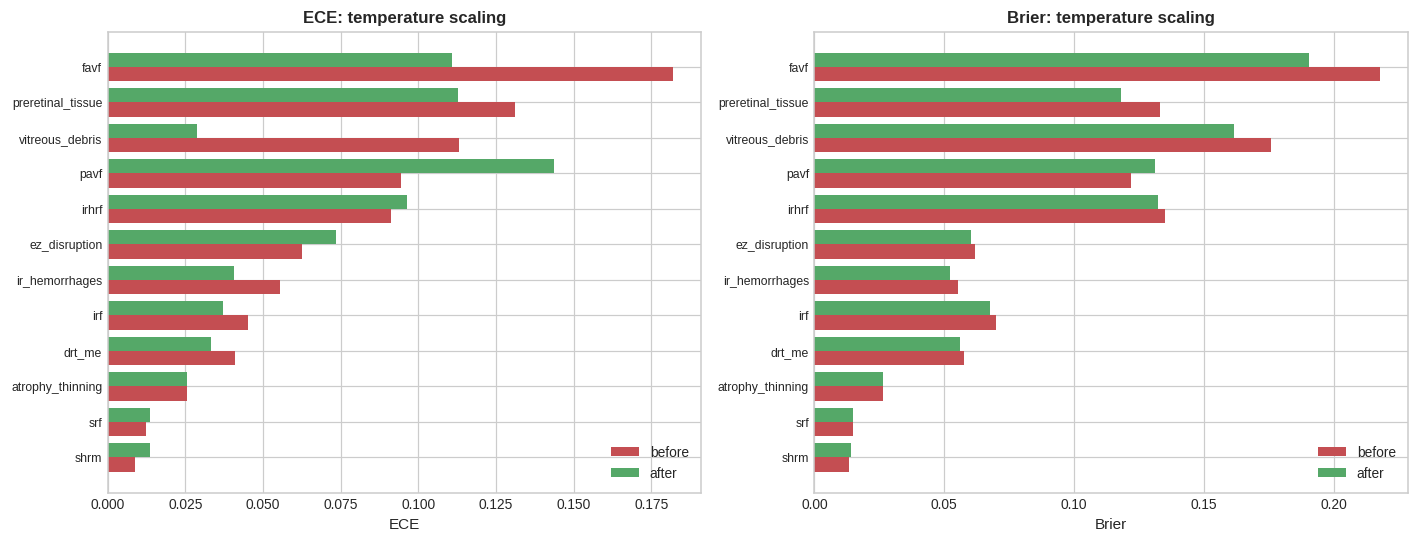

saved: /content/drive/MyDrive/olives/outputs/figures/phase4/01_calibration_comparison.png


In [7]:
show(plotter.calibration_comparison(calibration), "01_calibration_comparison")

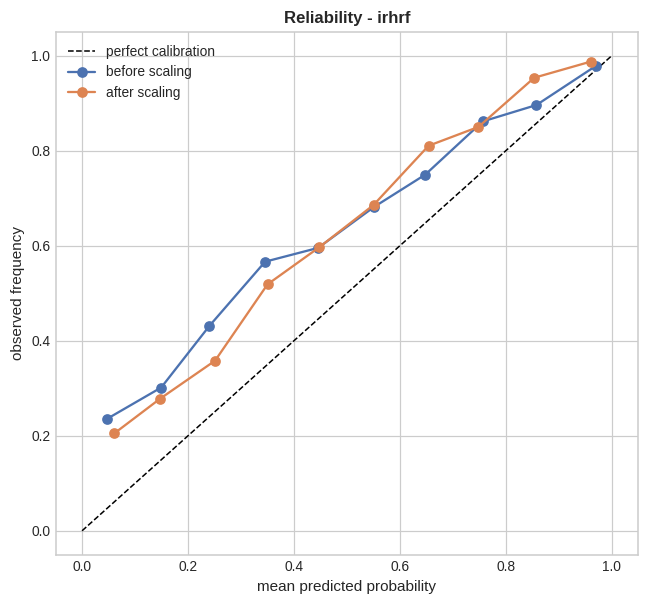

saved: /content/drive/MyDrive/olives/outputs/figures/phase4/02_reliability_irhrf.png


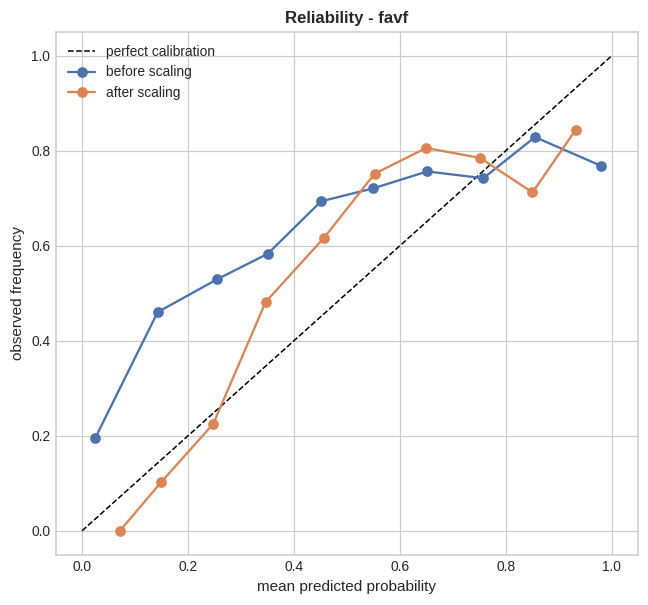

saved: /content/drive/MyDrive/olives/outputs/figures/phase4/02_reliability_favf.png


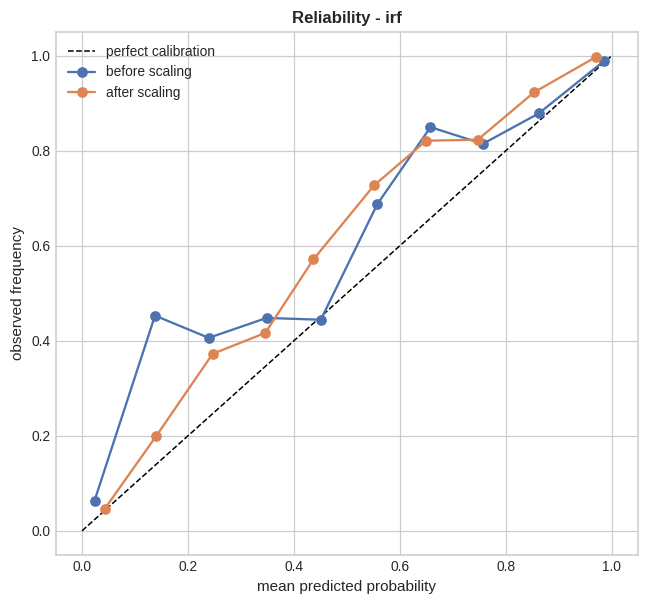

saved: /content/drive/MyDrive/olives/outputs/figures/phase4/02_reliability_irf.png


In [8]:
# Reliability diagrams for the labels that have enough positives to be readable.
test = result.test
calibrated = evaluator.calibrated_test_probabilities()
cal_eval = CalibrationEvaluator(n_bins=10)

readable = calibration[calibration["reliable"]].sort_values("n_positive", ascending=False)
for label in readable["label"].head(3):
    index = result.label_names.index(label)
    curves = {
        "before scaling": cal_eval.reliability_curve(test["targets"][:, index],
                                                     test["probabilities"][:, index]),
        "after scaling": cal_eval.reliability_curve(test["targets"][:, index],
                                                    calibrated[:, index]),
    }
    show(plotter.reliability_diagram(curves, title=f"Reliability - {label}"),
         f"02_reliability_{label}")

In [9]:
# Sanity check: calibration must not change the ranking.
from olives_biomarkers.evaluation import MultiLabelMetrics

metrics = MultiLabelMetrics(label_names=result.label_names)
before = metrics.compute(test["targets"], test["probabilities"], result.thresholds.as_array())
after = metrics.compute(test["targets"], calibrated, result.thresholds.as_array())

display(pd.DataFrame({"before": before, "after": after}).round(4))
print("macro_auroc should be identical before and after: temperature scaling is monotone.")
print("macro_f1 may move, because the frozen thresholds now sit at different probabilities.")

,before,after
macro_f1,0.5189,0.5004
micro_f1,0.7296,0.6443
macro_auroc,0.8505,0.8505
macro_auprc,0.5476,0.5476
macro_precision,0.3895,0.3579
macro_recall,0.5280,0.6045
macro_specificity,0.8685,0.7460
exact_match,0.1815,0.0044
hamming_loss,0.1166,0.1906
brier,0.0683,0.0650


macro_auroc should be identical before and after: temperature scaling is monotone.
macro_f1 may move, because the frozen thresholds now sit at different probabilities.


Note the caveat in that last line. Thresholds were fitted on **uncalibrated** validation
probabilities, so applying them to calibrated probabilities is technically inconsistent. Two
defensible options: report threshold-free metrics (AUROC/AUPRC) alongside calibration, or refit
thresholds on calibrated validation probabilities. The cell below does the latter so the
threshold-dependent numbers stay coherent.

In [10]:
# RunEvaluator owns this so the notebook and scripts/evaluate.py cannot diverge.
recalibrated_thresholds = evaluator.refit_thresholds_on_calibrated()

display(pd.DataFrame({
    "label": result.label_names,
    "threshold_uncalibrated": result.thresholds.as_array().round(3),
    "threshold_calibrated": recalibrated_thresholds.as_array().round(3),
}))

after_refit = metrics.compute(test["targets"], calibrated, evaluator.active_thresholds)
display(pd.DataFrame({
    "uncalibrated": before,
    "calibrated, old thresholds": after,
    "calibrated, refitted thresholds": after_refit,
}).round(4))

13:33:27 | WARNING | olives.metrics | label 'dril' is single-class in the validation fold; keeping threshold 0.5
13:33:28 | WARNING | olives.metrics | label 'vmt' is single-class in the validation fold; keeping threshold 0.5
13:33:28 | WARNING | olives.metrics | label 'rpe_disruption' is single-class in the validation fold; keeping threshold 0.5
13:33:28 | WARNING | olives.metrics | label 'ped_serous' is single-class in the validation fold; keeping threshold 0.5
13:33:29 | INFO    | olives.experiment | thresholds refitted on calibrated validation probabilities


,label,threshold_uncalibrated,threshold_calibrated
0,atrophy_thinning,0.0100,0.0100
1,ez_disruption,0.6400,0.6100
2,dril,0.5000,0.5000
3,ir_hemorrhages,0.0500,0.1400
4,irhrf,0.2700,0.3200
5,pavf,0.2200,0.4200
6,favf,0.1800,0.3800
7,preretinal_tissue,0.0200,0.1500
8,vitreous_debris,0.1400,0.3100
9,vmt,0.5000,0.5000


,uncalibrated,"calibrated, old thresholds","calibrated, refitted thresholds"
macro_f1,0.5189,0.5004,0.5261
micro_f1,0.7296,0.6443,0.7178
macro_auroc,0.8505,0.8505,0.8505
macro_auprc,0.5476,0.5476,0.5476
macro_precision,0.3895,0.3579,0.3929
macro_recall,0.5280,0.6045,0.5445
macro_specificity,0.8685,0.7460,0.8566
exact_match,0.1815,0.0044,0.1356
hamming_loss,0.1166,0.1906,0.1252
brier,0.0683,0.0650,0.0650


---
## 3. Monte Carlo dropout

Dropout is left active at inference and the model is run many times; the spread across passes is
the predictive uncertainty.

The implementation detail that matters: **only `nn.Dropout` modules are returned to train mode.**
Batch-norm layers stay in eval mode. If they did not, their running statistics would update and
predictions would depend on batch composition — that would be a batching artefact, not
uncertainty. There is a test asserting the running buffers do not move.

In [11]:
uncertainty = evaluator.estimate_uncertainty(n_passes=config.uncertainty.mc_dropout_passes)

print(f"{uncertainty.n_passes} stochastic passes over "
      f"{uncertainty.mean_probability.shape[0]:,} test scans")
print()
display(pd.DataFrame({
    "mean predictive std": uncertainty.std_probability.mean(axis=0),
    "mean predictive entropy": uncertainty.predictive_entropy.mean(axis=0),
    "mean mutual information": uncertainty.mutual_information.mean(axis=0),
}, index=result.label_names).round(4))

13:33:29 | INFO    | olives.uncertainty | MC dropout: 30 passes with 2 dropout modules active
30 stochastic passes over 1,372 test scans



,mean predictive std,mean predictive entropy,mean mutual information
atrophy_thinning,0.0123,0.0534,0.0052
ez_disruption,0.0283,0.1156,0.0117
dril,0.0114,0.0482,0.0048
ir_hemorrhages,0.0229,0.0925,0.0097
irhrf,0.0737,0.3538,0.0247
pavf,0.0627,0.2162,0.0292
favf,0.0887,0.2816,0.0442
preretinal_tissue,0.0451,0.1510,0.0221
vitreous_debris,0.0722,0.3011,0.0279
vmt,0.0021,0.0112,0.0009


In [12]:
# The entropy decomposition should hold exactly:
#   predictive entropy = expected entropy + mutual information
# Total uncertainty splits into what the data cannot resolve (aleatoric) and what
# the model is unsure about (epistemic).
residual = np.abs(
    uncertainty.mutual_information
    - (uncertainty.predictive_entropy - uncertainty.expected_entropy)
).max()
print(f"max decomposition residual: {residual:.2e}  (should be ~0)")

print(f"\nmean total uncertainty     : {uncertainty.total_uncertainty().mean():.4f}")
print(f"mean epistemic (MI)        : {uncertainty.epistemic_uncertainty().mean():.4f}")
share = uncertainty.epistemic_uncertainty().mean() / uncertainty.total_uncertainty().mean()
print(f"epistemic share of total   : {100 * share:.1f}%")
print()
print("A small epistemic share means most uncertainty is inherent ambiguity in the scans, which")
print("more training data would not fix. A large share suggests the model is under-trained or")
print("the test patients are genuinely out of distribution - plausible with 52 training patients.")

max decomposition residual: 0.00e+00  (should be ~0)

mean total uncertainty     : 0.1288
mean epistemic (MI)        : 0.0142
epistemic share of total   : 11.0%

A small epistemic share means most uncertainty is inherent ambiguity in the scans, which
more training data would not fix. A large share suggests the model is under-trained or
the test patients are genuinely out of distribution - plausible with 52 training patients.


---
## 4. Does uncertainty track error?

The claim "we can flag unreliable predictions" is only true if uncertain cases are actually more
often wrong. This is the test.

In [13]:
thresholds = evaluator.active_thresholds   # matches the calibrated probability scale
predictions = (calibrated >= thresholds).astype(int)
error_rate = (predictions != test["targets"]).mean(axis=1)
total_uncertainty = uncertainty.total_uncertainty()

selector = SelectivePredictor(label_names=result.label_names)
association = selector.uncertainty_error_association(
    test["targets"], calibrated, total_uncertainty, thresholds
)
display(pd.Series(association).to_frame("value").round(4))

if association["spearman_r"] > 0.1 and association["p_value"] < 0.05:
    print("\nUncertainty tracks error: abstaining on the most uncertain cases should help.")
else:
    print("\nUncertainty does NOT reliably track error on this test set. Selective prediction")
    print("cannot be recommended, and the coverage curve below will be flat or noisy.")

,value
spearman_r,0.5319
p_value,0.0000
mean_uncertainty_all_correct,0.0880
mean_uncertainty_any_wrong,0.1352



Uncertainty tracks error: abstaining on the most uncertain cases should help.


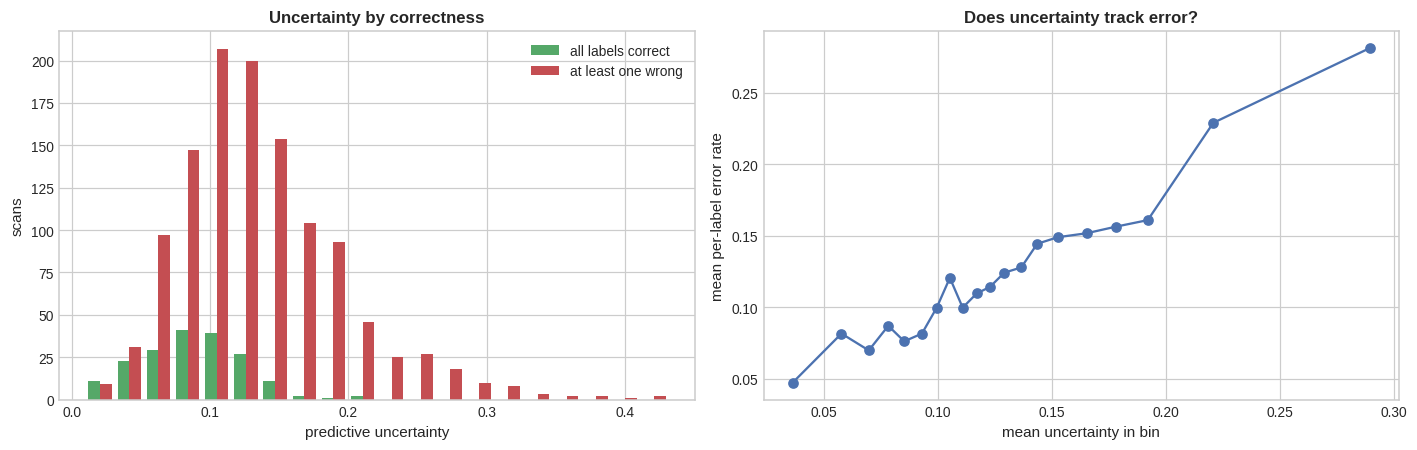

saved: /content/drive/MyDrive/olives/outputs/figures/phase4/03_uncertainty_vs_error.png


In [14]:
show(plotter.uncertainty_distribution(total_uncertainty, error_rate), "03_uncertainty_vs_error")

---
## 5. Selective prediction

If the model abstains on its least confident cases and refers them for human review, how much
does performance improve on the cases it keeps?

Any operating point must be chosen on validation or calibration data. Picking the coverage that
looks best on test is the selective-prediction version of tuning on the test set.

In [15]:
coverage, _ = evaluator.selective_prediction(
    coverage_levels=[1.0, 0.9, 0.8, 0.7, 0.6, 0.5]
)
coverage

,coverage,n_retained,n_abstained,macro_f1,macro_auroc,macro_auprc,hamming_loss,exact_match,uncertainty_cutoff
0,1.0000,1372,0,0.5261,0.8505,0.5476,0.1252,0.1356,0.4320
1,0.9000,1235,137,0.5932,0.8397,0.6233,0.1109,0.1490,0.2035
2,0.8000,1098,274,0.5983,0.8401,0.6183,0.1048,0.1667,0.1705
3,0.7000,960,412,0.5994,0.8353,0.6215,0.0983,0.1854,0.1471
4,0.6000,823,549,0.4824,0.8204,0.5038,0.0922,0.2017,0.1314
5,0.5000,686,686,0.5264,0.8006,0.5578,0.0872,0.2230,0.1194


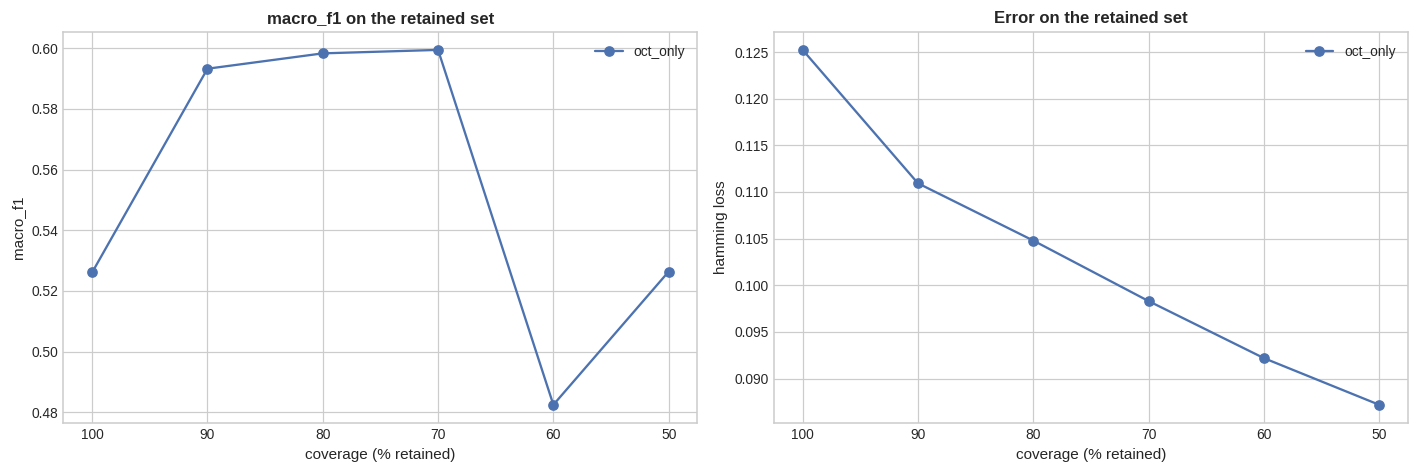

saved: /content/drive/MyDrive/olives/outputs/figures/phase4/04_coverage_curve.png


In [16]:
show(plotter.coverage_curve({result.model_name: coverage}, metric="macro_f1"),
     "04_coverage_curve")

In [17]:
full = coverage.loc[coverage["coverage"] == 1.0].iloc[0]
for level in [0.9, 0.8, 0.7]:
    row = coverage.loc[coverage["coverage"] == level]
    if row.empty:
        continue
    row = row.iloc[0]
    print(f"at {100 * level:.0f}% coverage ({int(row['n_abstained'])} scans referred):")
    print(f"    macro F1    {full['macro_f1']:.4f} -> {row['macro_f1']:.4f} "
          f"({row['macro_f1'] - full['macro_f1']:+.4f})")
    print(f"    hamming     {full['hamming_loss']:.4f} -> {row['hamming_loss']:.4f} "
          f"({row['hamming_loss'] - full['hamming_loss']:+.4f})")

at 90% coverage (137 scans referred):
    macro F1    0.5261 -> 0.5932 (+0.0672)
    hamming     0.1252 -> 0.1109 (-0.0143)
at 80% coverage (274 scans referred):
    macro F1    0.5261 -> 0.5983 (+0.0722)
    hamming     0.1252 -> 0.1048 (-0.0204)
at 70% coverage (412 scans referred):
    macro F1    0.5261 -> 0.5994 (+0.0734)
    hamming     0.1252 -> 0.0983 (-0.0269)


---
## 6. Case studies

The category worth studying is **confidently wrong**: predictions the model was sure about and
got wrong anyway. Those are the failures uncertainty did not catch, and they bound how much a
review workflow could ever help.

In [18]:
examples = selector.select_examples(
    test["targets"], calibrated, total_uncertainty, thresholds, n_per_category=5
)
for category, indices in examples.items():
    print(f"{category:22s}: {len(indices)} cases")

rows = []
for category, indices in examples.items():
    for index in indices[:3]:
        rows.append({
            "category": category,
            "patient_id": int(test["patient_id"][index]),
            "uncertainty": round(float(total_uncertainty[index]), 4),
            "n_labels_wrong": int((predictions[index] != test["targets"][index]).sum()),
            "true_labels": ", ".join(
                [l for l, v in zip(result.label_names, test["targets"][index]) if v == 1]
            ) or "(none)",
            "predicted": ", ".join(
                [l for l, v in zip(result.label_names, predictions[index]) if v == 1]
            ) or "(none)",
        })
pd.DataFrame(rows)

confidently_correct   : 5 cases
confidently_wrong     : 5 cases
uncertain_correct     : 5 cases
uncertain_wrong       : 5 cases


,category,patient_id,uncertainty,n_labels_wrong,true_labels,predicted
0,confidently_correct,251,0.0120,0,"irhrf, favf, drt_me, irf","irhrf, favf, drt_me, irf"
1,confidently_correct,251,0.0141,0,"irhrf, favf, drt_me, irf","irhrf, favf, drt_me, irf"
2,confidently_correct,251,0.0143,0,"irhrf, favf, drt_me, irf","irhrf, favf, drt_me, irf"
3,confidently_wrong,60,0.0097,1,"irhrf, favf, vitreous_debris, drt_me, irf","irhrf, favf, drt_me, irf"
4,confidently_wrong,207,0.0197,1,"irhrf, favf, drt_me, irf","irhrf, favf, preretinal_tissue, drt_me, irf"
5,confidently_wrong,95,0.0226,1,"irhrf, drt_me, irf","irhrf, favf, drt_me, irf"
6,uncertain_correct,243,0.1208,0,"irhrf, favf, preretinal_tissue, vitreous_debri...","irhrf, favf, preretinal_tissue, vitreous_debri..."
7,uncertain_correct,60,0.1214,0,"irhrf, pavf, irf","irhrf, pavf, irf"
8,uncertain_correct,90,0.1223,0,"favf, vitreous_debris","favf, vitreous_debris"
9,uncertain_wrong,207,0.1194,1,"irhrf, favf, vitreous_debris, drt_me, irf","irhrf, favf, preretinal_tissue, vitreous_debri..."


In [19]:
# Does the model ever predict PAVF and FAVF together? They are near mutually exclusive
# by definition, so that would be a concrete, checkable inconsistency.
if {"pavf", "favf"}.issubset(set(result.label_names)):
    p = result.label_names.index("pavf")
    f = result.label_names.index("favf")
    both = ((predictions[:, p] == 1) & (predictions[:, f] == 1)).sum()
    neither = ((predictions[:, p] == 0) & (predictions[:, f] == 0)).sum()
    truth_both = ((test["targets"][:, p] == 1) & (test["targets"][:, f] == 1)).sum()
    print(f"predicted BOTH pavf and favf : {both} scans ({100 * both / len(predictions):.1f}%)")
    print(f"ground truth has both        : {truth_both} scans")
    print(f"predicted NEITHER            : {neither} scans")
    print()
    print("The model treats labels independently, so it has no way to know these are")
    print("near-exclusive. A high 'both' count is a concrete argument for modelling label")
    print("structure - a clean, well-motivated extension rather than a vague 'future work'.")

predicted BOTH pavf and favf : 93 scans (6.8%)
ground truth has both        : 0 scans
predicted NEITHER            : 61 scans

The model treats labels independently, so it has no way to know these are
near-exclusive. A high 'both' count is a concrete argument for modelling label
structure - a clean, well-motivated extension rather than a vague 'future work'.


---
## 7. Save and summarise

In [20]:
uncertainty_frame = uncertainty.to_frame(result.label_names)
uncertainty_frame.to_parquet(result.run_dir / "test_uncertainty.parquet", index=False)
print("PHASE 4 SUMMARY")
print("=" * 60)
print(f"run                    : {result.run_id}")
print(f"MC dropout passes      : {uncertainty.n_passes}")
print(f"ECE (reliable labels)  : {reliable['ece_pre'].mean():.4f} -> "
      f"{reliable['ece_post'].mean():.4f}")
print(f"uncertainty~error rho  : {association['spearman_r']:.4f} "
      f"(p={association['p_value']:.2e})")
best = coverage.loc[coverage['macro_f1'].idxmax()]
print(f"best macro F1          : {best['macro_f1']:.4f} at "
      f"{100 * best['coverage']:.0f}% coverage")
print(f"\nartefacts written to {result.run_dir}")

PHASE 4 SUMMARY
run                    : oct_only_holdout_seed42_a100_20260828_190437
MC dropout passes      : 30
ECE (reliable labels)  : 0.0720 -> 0.0609
uncertainty~error rho  : 0.5319 (p=4.70e-101)
best macro F1          : 0.5994 at 70% coverage

artefacts written to /content/drive/MyDrive/olives/outputs/runs/colab_gpu/oct_only_holdout_seed42_a100_20260828_190437


### Reading this phase

- **Calibration is cheap and safe.** Temperature scaling cannot hurt ranking, and it needs only a
  held-out partition already carved out. Report both raw and calibrated numbers.
- **Uncertainty is only useful if it correlates with error.** The Spearman coefficient above is
  the evidence; without it, selective prediction is theatre.
- **None of this is a deployment claim.** A referral workflow would need prospective validation
  on a cohort this dataset cannot provide — one clinic, no untreated controls, 87 patients.

**Next:** `05_explainability_and_report.ipynb`.